# Exploratory Data Analysis

This notebook explores the AI4I 2020 Predictive Maintenance Dataset.

The objective is to understand the available machine features, inspect the
data quality, and analyze the distribution of machine failures before
building a predictive model.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from predictive_maintenance.data import load_data

sns.set_theme(style="whitegrid")

In [2]:
df = load_data()

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

df.head()

Loading local dataset from /Users/alexanderkorolev/Desktop/predictive-maintenance-ai4i/data/raw/ai4i2020.csv
Number of rows: 10000
Number of columns: 12


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Dataset structure

First, the shape, columns, and data types of the dataset are examined.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  str    
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
 7   TWF                  10000 non-null  int64  
 8   HDF                  10000 non-null  int64  
 9   PWF                  10000 non-null  int64  
 10  OSF                  10000 non-null  int64  
 11  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 937.6 KB


In [4]:
df.columns.tolist()

['Type',
 'Air temperature',
 'Process temperature',
 'Rotational speed',
 'Torque',
 'Tool wear',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature,10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature,10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed,10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque,10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear,10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.0,0.0,0.0,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.0,0.0,0.0,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.0,0.0,0.0,1.0
OSF,10000.0,0.00980,0.098514,0.0,0.0,0.0,0.0,1.0


## Data quality

The dataset is checked for missing values and duplicated observations.

In [6]:
missing_values = df.isna().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [7]:
duplicate_count = df.duplicated().sum()

print(f"Duplicated rows: {duplicate_count}")

Duplicated rows: 0


## Target distribution

The target variable indicates whether a machine failure occurred.
Its distribution is important because industrial failure datasets are
frequently imbalanced.

In [8]:
failure_counts = df["Machine failure"].value_counts().sort_index()
failure_percentages = (
    df["Machine failure"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

pd.DataFrame(
    {
        "Count": failure_counts,
        "Percentage": failure_percentages,
    }
)

,Count,Percentage
Machine failure,,
0,9661,96.61
1,339,3.39


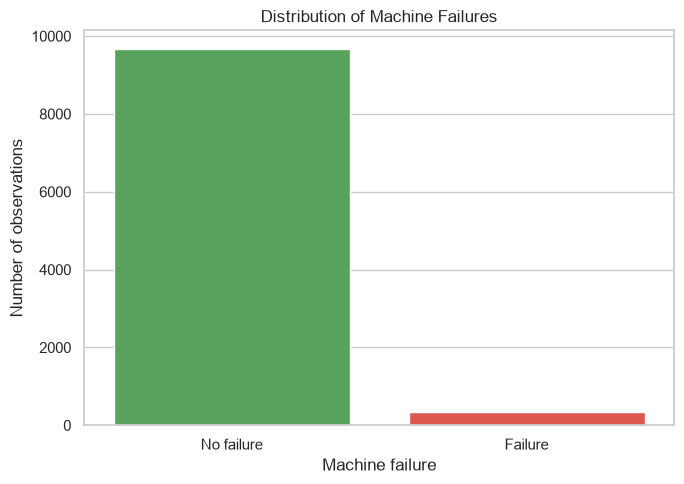

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Machine failure",
    hue="Machine failure",
    palette=["#4CAF50", "#F44336"],
    legend=False,
)

plt.title("Distribution of Machine Failures")
plt.xlabel("Machine failure")
plt.ylabel("Number of observations")
plt.xticks([0, 1], ["No failure", "Failure"])
plt.tight_layout()
plt.show()